# Sales Forecasting – Model Training

## Objective

This notebook focuses on training statistical time-series forecasting models using the prepared weekly sales dataset.

The workflow includes:

- Loading the processed weekly sales data
- Splitting the data into training and testing periods
- Building a baseline forecasting model
- Training multiple SARIMA candidate models
- Comparing models using AIC and BIC
- Selecting the best-performing model
- Generating forecasts on the test dataset
- Saving the final trained model and predictions

The evaluation of forecasting performance will be performed separately in the `04_model_evaluation.ipynb` notebook.

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pickle

## Load Dataset

In [3]:
weekly_sales = pd.read_csv(r"C:\Users\Lenovo\Customer-Intelligence-Platform\data\processed\Sales_forcasting_data\weekly_sales_1.csv",
                           index_col=0,
                           parse_dates=True)

weekly_sales.head()

,revenue,orders,rolling_4,rolling_8,revenue_diff
order_purchase_timestamp,,,,,
2017-01-08,3651.39,44,NaN,NaN,NaN
2017-01-15,12590.09,73,NaN,NaN,8938.70
2017-01-22,27209.61,189,NaN,NaN,14619.52
2017-01-29,60985.50,332,26109.1475,NaN,33775.89
2017-02-05,78392.75,432,44794.4875,NaN,17407.25


In [4]:
weekly_sales.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 86 entries, 2017-01-08 to 2018-08-26
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   revenue       86 non-null     float64
 1   orders        86 non-null     int64  
 2   rolling_4     83 non-null     float64
 3   rolling_8     79 non-null     float64
 4   revenue_diff  85 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 4.0 KB


In [5]:
weekly_sales.describe()

,revenue,orders,rolling_4,rolling_8,revenue_diff
count,86.000000,86.000000,83.000000,79.000000,85.000000
mean,178649.766395,1117.383721,180918.370663,181674.480981,1670.935059
std,84237.747342,527.545775,73668.226606,66821.171273,49363.699466
min,3651.390000,44.000000,26109.147500,47514.721250,-156283.660000
25%,118006.972500,754.750000,122207.398750,121163.951875,-13601.150000
50%,163454.890000,977.000000,171201.112500,208432.541250,4687.620000
75%,246507.145000,1552.500000,248232.032500,246583.577500,17115.350000
max,464219.770000,2915.000000,309639.632500,274880.641250,262841.670000


## Keep only target variable

In [6]:
sales = weekly_sales["revenue"].copy()

In [7]:
sales.head()

order_purchase_timestamp
2017-01-08     3651.39
2017-01-15    12590.09
2017-01-22    27209.61
2017-01-29    60985.50
2017-02-05    78392.75
Name: revenue, dtype: float64

## Train Test Split

In [8]:
train_size = int(len(sales) * 0.8)

train = sales.iloc[:train_size]
test = sales.iloc[train_size:]

In [9]:
print(f"Training observations : {len(train)}")
print(f"Testing observations  : {len(test)}")

Training observations : 68
Testing observations  : 18


## Visualize the split

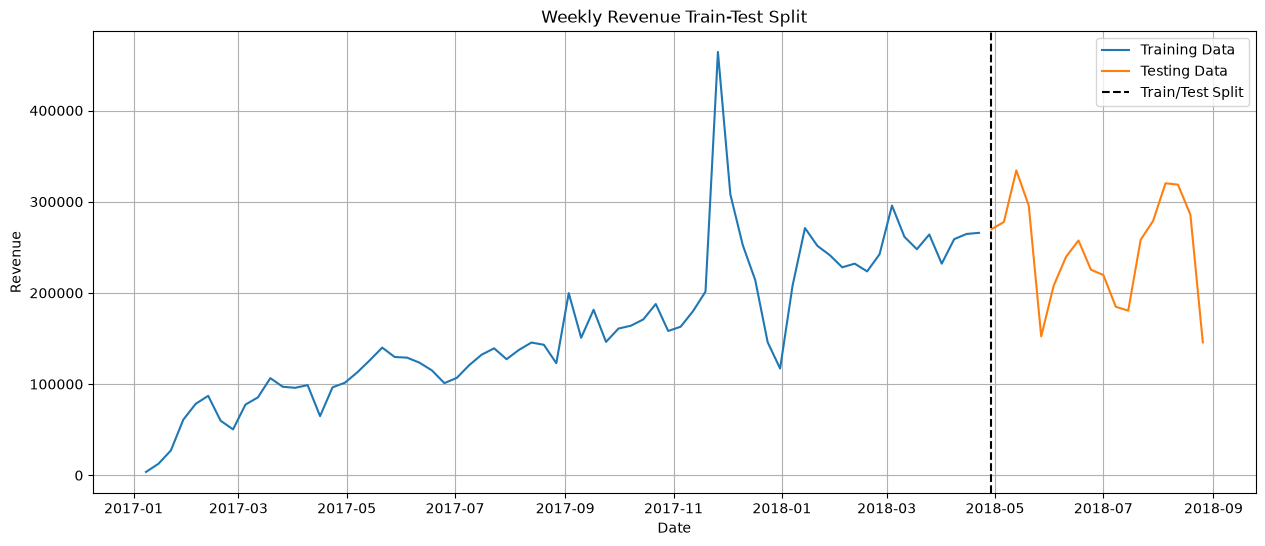

In [11]:
plt.figure(figsize=(15,6))

plt.plot(
    train,
    label="Training Data"
)

plt.plot(
    test,
    label="Testing Data"
)

plt.axvline(
    test.index[0],
    color="black",
    linestyle="--",
    label="Train/Test Split"
)

plt.title("Weekly Revenue Train-Test Split")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

## Train–Test Split

The weekly revenue time series was divided chronologically into training and testing subsets using an 80–20 ratio.

Unlike traditional machine learning problems, time-series forecasting must preserve temporal order to avoid information leakage.

The training data contains historical observations used to fit forecasting models, while the testing data represents future unseen observations used to evaluate forecasting performance.

## Baseline Forecasting Model

### Baseline 1: Naive Forecast

In [12]:
train.iloc[-1]

np.float64(265831.64)

In [15]:
test.index

DatetimeIndex(['2018-04-29', '2018-05-06', '2018-05-13', '2018-05-20',
               '2018-05-27', '2018-06-03', '2018-06-10', '2018-06-17',
               '2018-06-24', '2018-07-01', '2018-07-08', '2018-07-15',
               '2018-07-22', '2018-07-29', '2018-08-05', '2018-08-12',
               '2018-08-19', '2018-08-26'],
              dtype='datetime64[us]', name='order_purchase_timestamp', freq=None)

#### Implementation

In [16]:
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

### Visualize

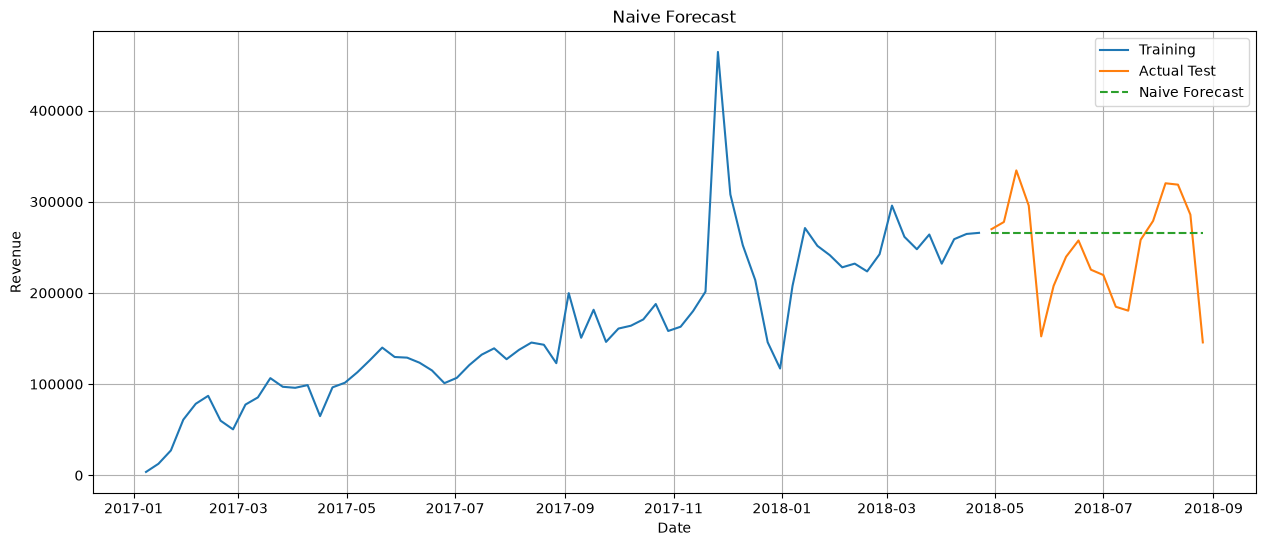

In [17]:
plt.figure(figsize=(15,6))

plt.plot(
    train,
    label="Training"
)

plt.plot(
    test,
    label="Actual Test"
)

plt.plot(
    naive_forecast,
    label="Naive Forecast",
    linestyle="--"
)

plt.title("Naive Forecast")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

### Baseline 2: Moving Average Forecast

In [18]:
moving_avg = train.tail(4).mean()

ma_forecast = pd.Series(
    moving_avg,
    index=test.index
)

### Visualize

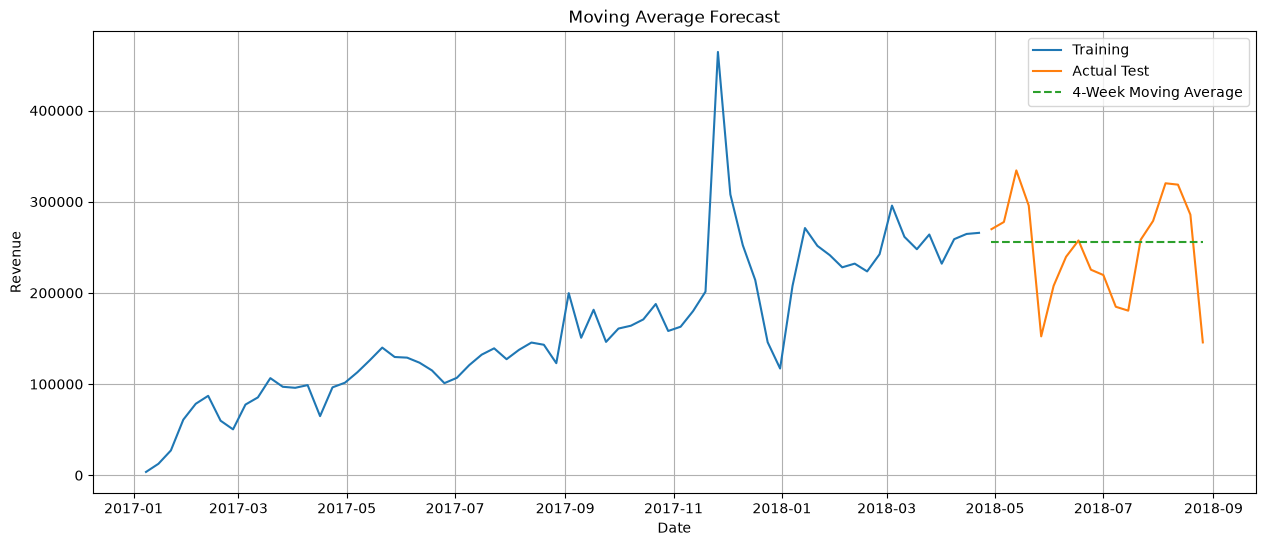

In [19]:
plt.figure(figsize=(15,6))

plt.plot(
    train,
    label="Training"
)

plt.plot(
    test,
    label="Actual Test"
)

plt.plot(
    ma_forecast,
    label="4-Week Moving Average",
    linestyle="--"
)

plt.title("Moving Average Forecast")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

## Compare the Baseline Model

In [21]:
from sklearn.metrics import mean_absolute_percentage_error
baseline_results = pd.DataFrame({
    "Model": [],
    "MAE": [],
    "RMSE": [],
    "MAPE": []
})

### Naive

In [22]:
naive_mae = mean_absolute_error(test, naive_forecast)

naive_rmse = np.sqrt(
    mean_squared_error(test, naive_forecast)
)

naive_mape = mean_absolute_percentage_error(
    test,
    naive_forecast
)

### Moving Average

In [23]:
ma_mae = mean_absolute_error(test, ma_forecast)

ma_rmse = np.sqrt(
    mean_squared_error(test, ma_forecast)
)

ma_mape = mean_absolute_percentage_error(
    test,
    ma_forecast
)

### Results Table

In [24]:
baseline_results = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Moving Average"
    ],
    "MAE": [
        naive_mae,
        ma_mae
    ],
    "RMSE": [
        naive_rmse,
        ma_rmse
    ],
    "MAPE": [
        naive_mape,
        ma_mape
    ]
})

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Forecast,46751.393333,58302.941582,0.229887
1,Moving Average,46143.296667,55875.432501,0.218602


## Baseline Forecasting Models

Before training SARIMA models, two simple forecasting methods were implemented to establish benchmark performance.

**Naïve Forecast**
- Assumes future revenue will be equal to the most recent observed value.

**4-Week Moving Average Forecast**
- Uses the average revenue of the previous four weeks as the forecast for future periods.

These baseline models provide reference performance levels. The SARIMA model should outperform these methods to justify its additional complexity.

## Baseline Forecast Performance

Two benchmark forecasting approaches were evaluated before training SARIMA models.

| Model | MAE | RMSE | MAPE |
|-------|----:|-----:|------:|
| Naïve Forecast | 46,751 | 58,303 | 22.99% |
| 4-Week Moving Average | 46,143 | 55,875 | 21.86% |

The 4-week moving average produced lower forecasting errors than the naïve forecast across all evaluation metrics.

These benchmark models establish a performance baseline for subsequent SARIMA models. The final forecasting model should outperform these simple approaches to justify the use of a more sophisticated statistical model.

## Train Candidate SARIMA Models

### Candidate Orders

In [25]:
candidate_orders = [
    (0,1,0),
    (1,1,0),
    (0,1,1),
    (1,1,1),
    (2,1,1),
    (1,1,2)
]

### Train All Models

In [26]:
results = []

for order in candidate_orders:

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=(0,0,0,4),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        results.append({
            "Order": order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic
        })

    except Exception as e:

        print(f"{order} failed")

### Compare Models

In [27]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("AIC")

results_df

,Order,AIC,BIC
5,"(1, 1, 2)",1557.319277,1565.954809
3,"(1, 1, 1)",1579.895239,1586.418401
4,"(2, 1, 1)",1581.558415,1590.255964
2,"(0, 1, 1)",1583.732053,1588.080827
1,"(1, 1, 0)",1608.062935,1612.442245
0,"(0, 1, 0)",1608.532326,1610.721981


### Select the Best Model

In [28]:
best_order = results_df.iloc[0]["Order"]

print("Best Order:", best_order)

Best Order: (1, 1, 2)


### Forecast the test set

In [29]:
final_model = SARIMAX(
    train,
    order=(1,1,2),
    seasonal_order=(0,0,0,4),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

### Generate Forecast

In [30]:
forecast = final_model.get_forecast(steps=len(test))

predictions = forecast.predicted_mean

confidence_interval = forecast.conf_int()

### Store the results

In [31]:
forecast_df = pd.DataFrame({
    "Actual": test,
    "Predicted": predictions
})

forecast_df.head()

,Actual,Predicted
2018-04-29,269879.70,260546.397830
2018-05-06,277743.55,258016.020304
2018-05-13,334320.93,257083.579653
2018-05-20,295686.95,256739.976550
2018-05-27,152343.99,256613.359278


### Visualize the Forecast

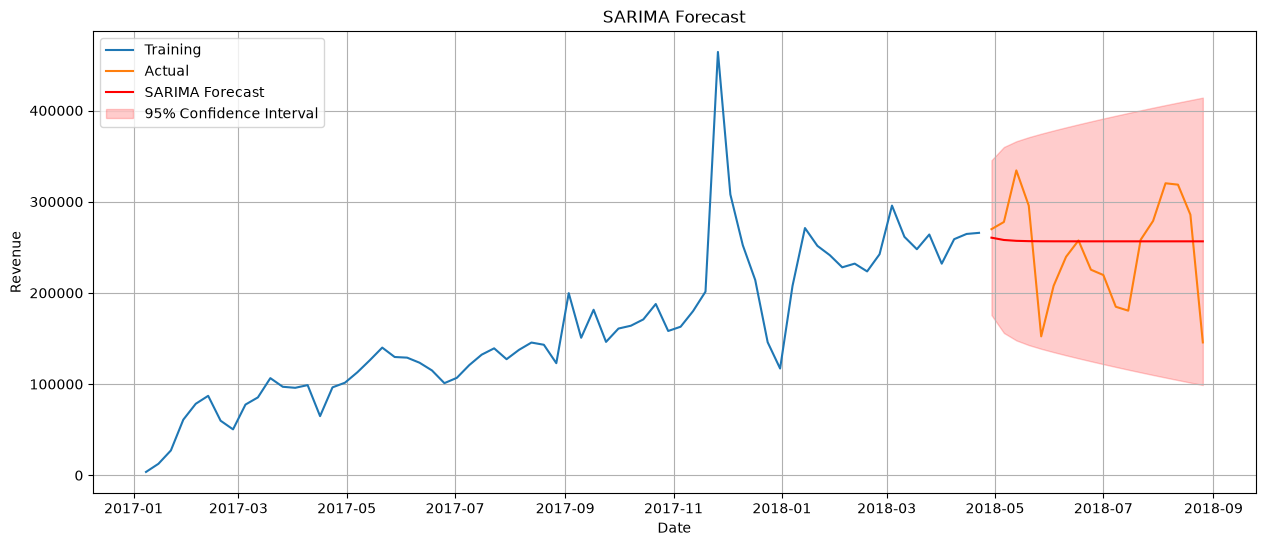

In [32]:
plt.figure(figsize=(15,6))

plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(predictions, label="SARIMA Forecast", color="red")

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:, 0],
    confidence_interval.iloc[:, 1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
forecast_df.to_csv("../../data/processed/Sales_forcasting_data/sarima_predictions.csv")

with open("../../model/final_sarima.pkl", "wb") as f:
    pickle.dump(final_model, f)